In [1]:
import pandas as pd

df = pd.read_csv("./data/accepted_2007_to_2018Q4.csv")


C:\Users\user\AppData\Local\Temp\ipykernel_32736\3222001558.py:3: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/accepted_2007_to_2018Q4.csv")


In [2]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
# 결측치 확인
print(df.isnull().sum())


id                                                  0
member_id                                     2260701
loan_amnt                                          33
funded_amnt                                        33
funded_amnt_inv                                    33
term                                               33
int_rate                                           33
installment                                        33
grade                                              33
sub_grade                                          33
emp_title                                      167002
emp_length                                     146940
home_ownership                                     33
annual_inc                                         37
verification_status                                33
issue_d                                            33
loan_status                                        33
pymnt_plan                                         33
url                         

In [5]:
df.shape

(2260701, 151)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 2.5+ GB


In [7]:
df.dtypes

id                                             object
member_id                                     float64
loan_amnt                                     float64
funded_amnt                                   float64
funded_amnt_inv                               float64
term                                              str
int_rate                                      float64
installment                                   float64
grade                                             str
sub_grade                                         str
emp_title                                         str
emp_length                                        str
home_ownership                                    str
annual_inc                                    float64
verification_status                               str
issue_d                                           str
loan_status                                       str
pymnt_plan                                        str
url                         

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2260701.0,2260701.0,68407277.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,NaN,NaN,NaN,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,NaN,NaN,NaN,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,NaN,NaN,NaN,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
term,2260668,2,36 months,1609754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_rate,2260668.0,NaN,NaN,NaN,13.092829,4.832138,5.31,9.49,12.62,15.99,30.99
installment,2260668.0,NaN,NaN,NaN,445.806823,267.173535,4.93,251.65,377.99,593.32,1719.83
grade,2260668,7,B,663557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_grade,2260668,35,C1,145903,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 데이터전처리
1) 데이터 정제
    - 중복 제거
    - 타입 변환
    - 컬럼명 정제
2) 데이터 병합
    - 단일 테이블이라 필요없음
3) 결측치 처리
    - 개수 확인
    - 행 직접 확인
    - 대체 방법 결정
4) 이상치 처리
    - 박스플룻으로 확인
    - 왜도/첨도 확인
    - 기초통계 확인
    - 시각화로 확인(qq plot도?)
    - 도메인 지식으로 이상치 처리
5) 파생변수 생성
    - 분석 목적에 맞게 고민
6) 데이터셋 저장


### 데이터 전처리 시작!!

In [9]:
# 데이터 전처리 시작
# loan_status 열의 고유값 및 개수 확인
print(df["loan_status"].value_counts())


loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [10]:
# 타겟 변수 생성 및 이진 분류 문제로 변환

# loan_status 의 charged off와 default를 1로 fully paid만 0으로 변환
# 1: Charged Off, Default / 0: Fully Paid / 나머지 상태: NaN
status_map = {
    'Charged Off': 1,
    'Default': 1,
    'Fully Paid': 0
}

df['target'] = df['loan_status'].map(status_map) # loan_status 열의 값을 status_map에 따라 변환하여 target 열에 저장


df_bin = df[df['target'].notna()].copy() # target 열이 NaN이 아닌 행들만 필터링하여 df_bin에 저장
df_bin['target'] = df_bin['target'].astype(int) # target 열의 데이터 타입을 정수형으로 변환 (0과 1로 이루어진 이진 분류 문제로 만들기 위해)



C:\Users\user\AppData\Local\Temp\ipykernel_32736\1823338913.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['loan_status'].map(status_map) # loan_status 열의 값을 status_map에 따라 변환하여 target 열에 저장


In [11]:
# 데이터 전처리를 위한 데이터 누수 위험 변수 제거를 위한 컬럼명 리스트
# 전체 컬럼명을 리스트 형태로 출력하여 확인하기
all_columns = df_bin.columns.tolist()

# 너무 길면 보기 힘드니 10개씩 끊어서 출력해보기
for i in range(0, len(all_columns), 10):
    print(all_columns[i:i+10])

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade']
['emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']
['purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths']
['mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv']
['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d']
['last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint']
['acc_now_de

In [12]:
df_bin.shape

(1345350, 152)

## PART 1 데이터 누수 위험 및 불필요한 컬럼 정리

In [26]:
# 1. 누수가 100% 확실한 사후 데이터 리스트 및 모델 학습에 무의미한 식별자와 상수 컬럼 정의
leakage_cols_confirmed = [
    # 그룹 1: 사후상환실적
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 
    'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',
    # 그룹 2: 잔액사후정보
    'out_prncp', 'out_prncp_inv',
    # 그룹 3: 상각/추심사후
    'recoveries', 'collection_recovery_fee',
    # 그룹 4: 사후신용스냅샷
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # 그룹 5: 사후특별상환계획 및 부채조정
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 
    'hardship_length', 'hardship_dpd', 'hardship_loan_status', 
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'orig_projected_additional_accrued_interest',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',

    # 그룹 6: 특별상환계획
    'pymnt_plan', 'payment_plan_start_date',
        
    # 그룹 7: 승인/집행결과 (대출 승인 후 실제 집행까지의 결과를 나타내는 변수들)
    'funded_amnt', 'funded_amnt_inv', 'disbursement_method', 
    
    # 그룹 8: 기타 식별자 및 상수 컬럼
    'id', 'member_id', 'url', 'title', 'zip_code', 'policy_code', 'desc', # 'policy_code'는 모든 행에서 동일한 값(1)으로 상수 컬럼이므로 제거 대상

    # 그룹 9: 원본 타겟 변수
    'loan_status', # 원본 타겟 변수도 모델 학습에 들어가면 안 되므로 제거 대상

    # 그룹 10: 효과크기가 낮은 변수들
    # "open_acc", "application_type", "addr_state", "earliest_cr_line", "pub_rec"

]

# 2. 확실한 누수 변수 제거 진행
df_cleaned = df_bin.drop(columns=leakage_cols_confirmed, errors='ignore') 

print(f"1차로 제거된 변수 개수: {len(leakage_cols_confirmed)}개")
print(f"누수 변수 1차 제거 후 데이터 형태(행, 열): {df_cleaned.shape}")



1차로 제거된 변수 개수: 49개
누수 변수 1차 제거 후 데이터 형태(행, 열): (1345350, 103)


## PART 2 결측치 비율에 따른 컬럼 정리
- 과연 50% 이상이라고 다 지우는 것이 맞는가?
- 그룹 1: 공동 차주(Joint / Secondary Applicant) 관련 변수 (16개)
- 그룹 2: 특정 신용 사건 발생 후 경과 시간 (6개)
- 그룹 3: 신규 추가된 세부 신용 리포트 항목 (13개)


In [16]:
# 도메인 기반 신규 추가된 세부 신용 리포트 항목을 제거할 것인가?
# 2015년 12월 이후로 추가된 항목들로 이전 데이터는 존재하지 않아 결측치가 50% 이상인 컬럼들이 많습니다.

g3 = [
    'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
    'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m',
    'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m'
]

# 결측치 비율까지 같이
na_summary = pd.DataFrame({
    'na_count': df_cleaned[g3].isna().sum(),
    'na_ratio': df_cleaned[g3].isna().mean()
}).sort_values('na_count', ascending=False)
display(na_summary)


,na_count,na_ratio
il_util,880303,0.654330
all_util,807767,0.600414
total_cu_tl,807715,0.600375
inq_last_12m,807715,0.600375
open_acc_6m,807715,0.600375
total_bal_il,807714,0.600375
open_il_24m,807714,0.600375
open_il_12m,807714,0.600375
open_act_il,807714,0.600375
max_bal_bc,807714,0.600375


C:\Users\user\AppData\Local\Temp\ipykernel_32736\2373788677.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmp['issue_d'] = pd.to_datetime(tmp['issue_d'], errors='coerce') # %b-%Y 형식으로 변환 (예: Jan-2015)


,open_acc_6m,open_act_il,open_il_12m,open_il_24m,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,inq_fi,total_cu_tl,inq_last_12m
issue_d,,,,,,,,,,,,,
Jun-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Jul-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Aug-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Sep-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Oct-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Nov-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Dec-2007,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Jan-2008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Feb-2008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


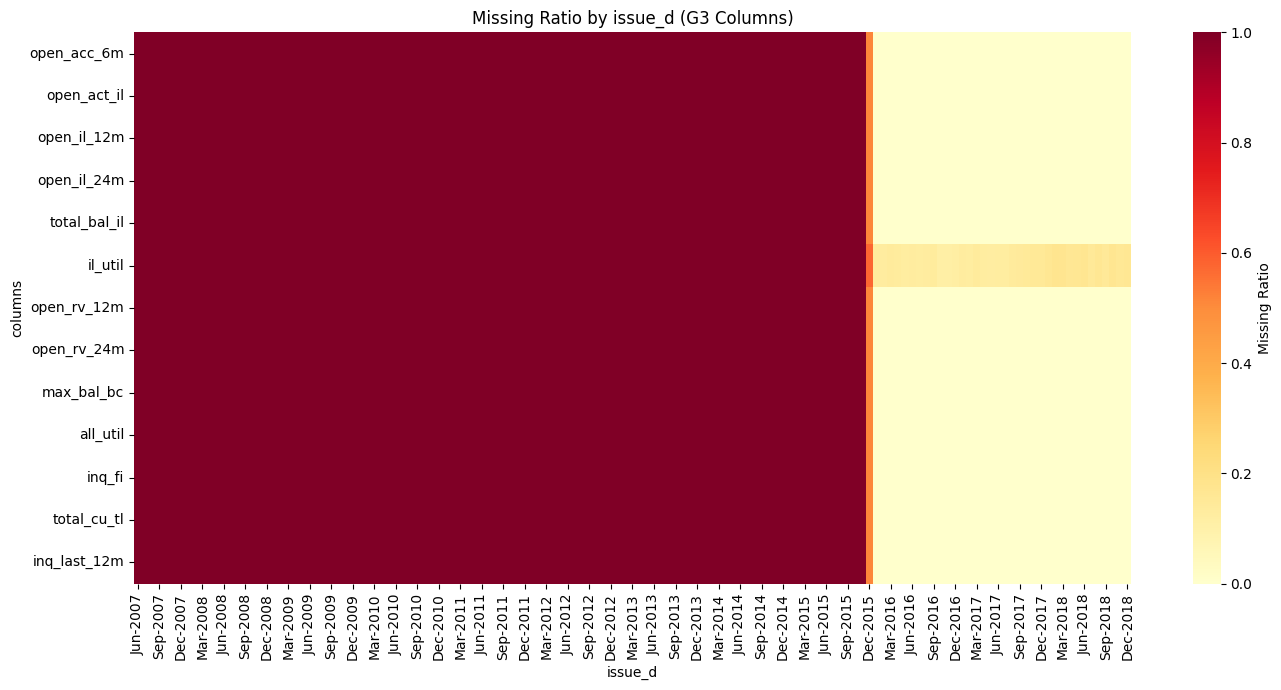

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# issue_d를 datetime으로 맞춰두기
tmp = df_cleaned.copy()
tmp['issue_d'] = pd.to_datetime(tmp['issue_d'], errors='coerce') # %b-%Y 형식으로 변환 (예: Jan-2015)

# 월별 결측률 테이블
na_tbl = (
    tmp.groupby('issue_d')[g3]
       .apply(lambda x: x.isna().mean())
       .round(3)
       .sort_index()
)

# datetime 인덱스를 'Jan-2015' 형식의 문자열로 변환
na_tbl.index = na_tbl.index.strftime('%b-%Y') 

display(na_tbl)

# 히트맵
plt.figure(figsize=(14, 7))
sns.heatmap(
    na_tbl.T,               # 컬럼을 행으로 돌리면 변수별 패턴 보기 좋음
    cmap='YlOrRd',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Missing Ratio'}
)
plt.title('Missing Ratio by issue_d (G3 Columns)')
plt.xlabel('issue_d')
plt.ylabel('columns')
plt.tight_layout()
plt.show()


# 확인된 패턴
- 2015-11까지 거의 전결측
- 2015-12 전환 구간(약 50% 결측)
- 2016 이후 대부분 결측 거의 0
- 단, il_util은 2016 이후에도 약 0.1 수준 결측 지속

# 모델링, 전처리 전략
- 제외 모델: 그룹3 제외
- 포함 모델: 그룹3 포함
    - 포함A : 전체 기간 포함(2016 이전 결측치는 대체)
    - 포함B : 2016 이후 기간만 포함

In [18]:
count_before_2015_12 = (tmp['issue_d'] <= pd.Timestamp('2015-12-01')).sum()
print("2015-12 이전(=2015-11까지) 행 개수:", count_before_2015_12)
count_after_2015_12 = (tmp['issue_d'] > pd.Timestamp('2015-12-01')).sum()
print("2015-12 이후 행 개수:", count_after_2015_12)


2015-12 이전(=2015-11까지) 행 개수: 826606
2015-12 이후 행 개수: 518744


## il_util의 분포 확인 및 결측치 대체 대푯값 선정


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


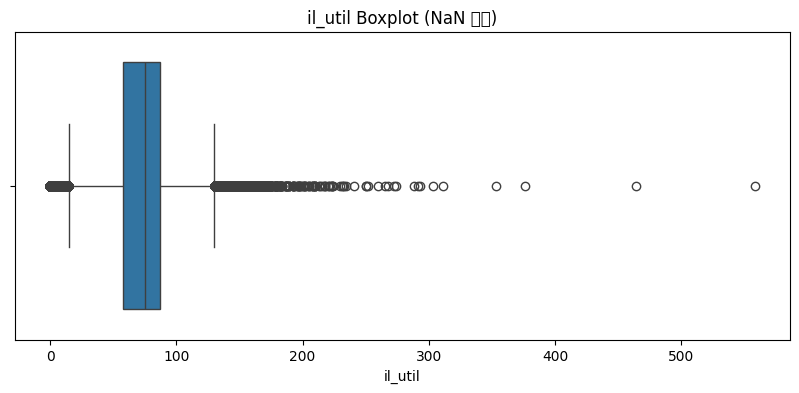

mean   : 71.42212937617057
median : 75.0
mode   : 83.0
Q1/Q3  : 58.0 87.0
NaN 비율: 0.6543300999739845


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 숫자형 변환 (문자 섞임 대비)
s = pd.to_numeric(df_cleaned['il_util'], errors='coerce')

# 결측 제외 분포 확인
plt.figure(figsize=(10, 4))
sns.boxplot(x=s.dropna())
plt.title('il_util Boxplot (NaN 제외)')
plt.xlabel('il_util')
plt.show()

# 대푯값 참고치 함께 확인
print("mean   :", s.mean())
print("median :", s.median())
print("mode   :", s.mode().iloc[0] if not s.mode().empty else None)
print("Q1/Q3  :", s.quantile(0.25), s.quantile(0.75))
print("NaN 비율:", s.isna().mean())


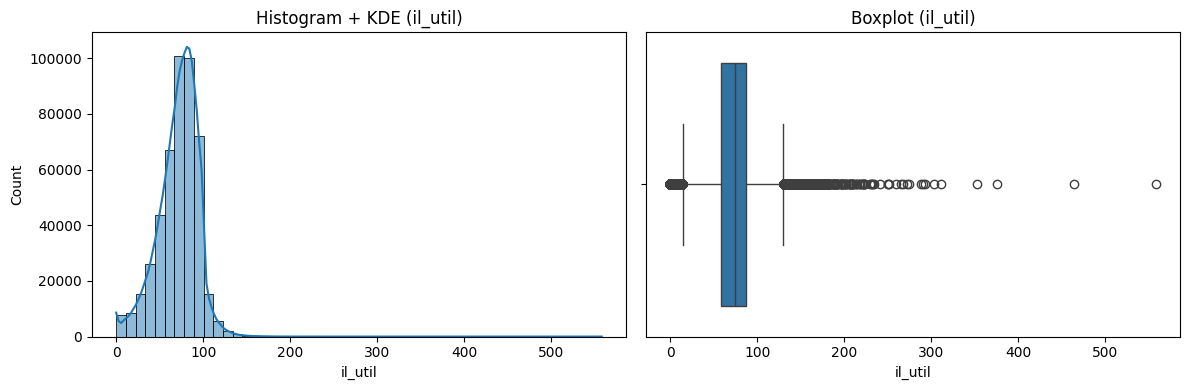

skewness(왜도): -0.45153974600555513
kurtosis(첨도): 1.7386766099014959
Shapiro p-value: 3.142316307232801e-46
D'Agostino p-value: 0.0


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest

s = pd.to_numeric(df_cleaned['il_util'], errors='coerce').dropna()

# 1) 시각적으로 분포 확인 - 히스토그램 + KDE, 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(s, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Histogram + KDE (il_util)')

sns.boxplot(x=s, ax=axes[1])
axes[1].set_title('Boxplot (il_util)')
plt.tight_layout()
plt.show()

# 2) 수치 요약
print("skewness(왜도):", s.skew())
print("kurtosis(첨도):", s.kurt())

# 3) 정규성 검정 (표본이 너무 크면 일부 샘플링 권장)
sample = s.sample(min(len(s), 5000), random_state=42)
print("Shapiro p-value:", shapiro(sample).pvalue)
print("D'Agostino p-value:", normaltest(sample).pvalue)


# il_util 결측 대체값으로 중앙값이 적절한 이유
- 분포가 정규분포가 아님
- Shapiro, D’Agostino 검정 p-value가 매우 작아 정규성 가정이 깨짐
- 평균 기반 대체의 전제가 약함

# 왜도/첨도 특성
- 왜도 -0.45(약한 비대칭), 첨도 1.74(꼬리 두꺼움)
- 평균은 꼬리값/극단값 영향이 커서 대표값으로 흔들릴 수 있음
- 중앙값은 극단값에 강건(robust)
- 이상치 미처리 상태에서도 안정적
- 현재 이상치 제거 전 단계라 평균보다 중앙값이 더 안전한 기본 선택
- 이상치 처리 후엔 모델 성능으로 비교하는게 바람직?
- 실무 베이스라인 관행과 부합
- 신용/대출 데이터의 수치형 결측 대체에서 중앙값 + 결측 플래그 조합이 흔히 사용됨
- 성능/해석 안정성 측면에서 무난함

# 요약:
- il_util은 비정규 + 꼬리 영향이 있는 변수라 평균보다 중앙값 대체가 더 안정적이고,
- il_util_isna 플래그를 함께 두면 결측 자체의 정보도 보존할 수 있습니다.

In [101]:
# 결국 13개 컬럼은 제거하기로함
df_cleaned_v2 = df_cleaned.drop(columns=g3, errors='ignore')

g1 = [
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog'
]
# 공동 신청자 관련 변수들로, 공동 신청자 정보가 없는 경우가 많아 결측치가 많고 모델 학습에 큰 도움이 되지 않을 것으로 판단되어 제거
df_cleaned_v3 = df_cleaned_v2.drop(columns=g1, errors='ignore')

# 2차로 제거된 변수 개수와 최종 데이터 형태 출력
print(f"2차로 제거된 변수 개수: {len(g1)}개")
print(f"최종 누수 변수 제거 후 데이터 형태(행, 열): {df_cleaned_v3.shape}")


2차로 제거된 변수 개수: 16개
최종 누수 변수 제거 후 데이터 형태(행, 열): (1345350, 74)


## 각자 15개씩 맡아서 이상치, 결측치 처리방안 모색하기


In [ ]:
# 결측치와 이상치 처리
cols = ["num_bc_tl", "num_il_tl", "num_op_rev_tl", "num_rev_accts", "num_rev_tl_bal_gt_0",
            "num_sats", "num_tl_op_past_12m", "acc_open_past_24mths", "mort_acc", "tot_cur_bal",
            "avg_cur_bal", "tot_coll_amt", "tot_hi_cred_lim", "total_bal_ex_mort", "total_il_high_credit_limit"]

In [58]:
# cols리스트 안 변수들의 데이터 타입 확인
for col in cols:
    print(f"{col}: {df_cleaned_v3[col].dtype}")


num_bc_tl: float64
num_il_tl: float64
num_op_rev_tl: float64
num_rev_accts: float64
num_rev_tl_bal_gt_0: float64
num_sats: float64
num_tl_op_past_12m: float64
acc_open_past_24mths: float64
mort_acc: float64
tot_cur_bal: float64
avg_cur_bal: float64
tot_coll_amt: float64
tot_hi_cred_lim: float64
total_bal_ex_mort: float64
total_il_high_credit_limit: float64


# 이상치 처리 방안 모색


In [44]:
# 이상치를 describe로 대푯값과 함께 확인
desc = df_cleaned_v3[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
display(desc)

# 음수 존재 여부(도메인 룰 체크)
neg_chk = (df_cleaned_v3[cols] < 0).sum().sort_values(ascending=False)
display(neg_chk[neg_chk > 0])


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
num_bc_tl,1277823.0,8.101079,4.800903,0.0,1.0,2.0,5.0,7.0,11.0,17.0,23.00,70.0
num_il_tl,1277823.0,8.567874,7.386593,0.0,0.0,1.0,4.0,7.0,11.0,23.0,35.00,159.0
num_op_rev_tl,1277823.0,8.278835,4.558054,0.0,2.0,3.0,5.0,7.0,10.0,17.0,23.00,83.0
num_rev_accts,1277822.0,14.610277,8.119393,0.0,3.0,5.0,9.0,13.0,19.0,30.0,41.00,128.0
num_rev_tl_bal_gt_0,1277823.0,5.592638,3.215282,0.0,1.0,2.0,3.0,5.0,7.0,12.0,16.00,45.0
num_sats,1289509.0,11.639063,5.482548,0.0,3.0,5.0,8.0,11.0,14.0,22.0,29.00,90.0
num_tl_op_past_12m,1277823.0,2.178893,1.845049,0.0,0.0,0.0,1.0,2.0,3.0,5.0,8.00,32.0
acc_open_past_24mths,1298069.0,4.692894,3.186910,0.0,0.0,1.0,2.0,4.0,6.0,11.0,15.00,64.0
mort_acc,1298069.0,1.670769,2.000441,0.0,0.0,0.0,0.0,1.0,3.0,6.0,8.00,51.0
tot_cur_bal,1277823.0,141133.296302,157547.322995,0.0,3094.0,8625.0,29423.0,80231.0,210715.0,433473.9,674281.48,8000078.0


Series([], dtype: int64)

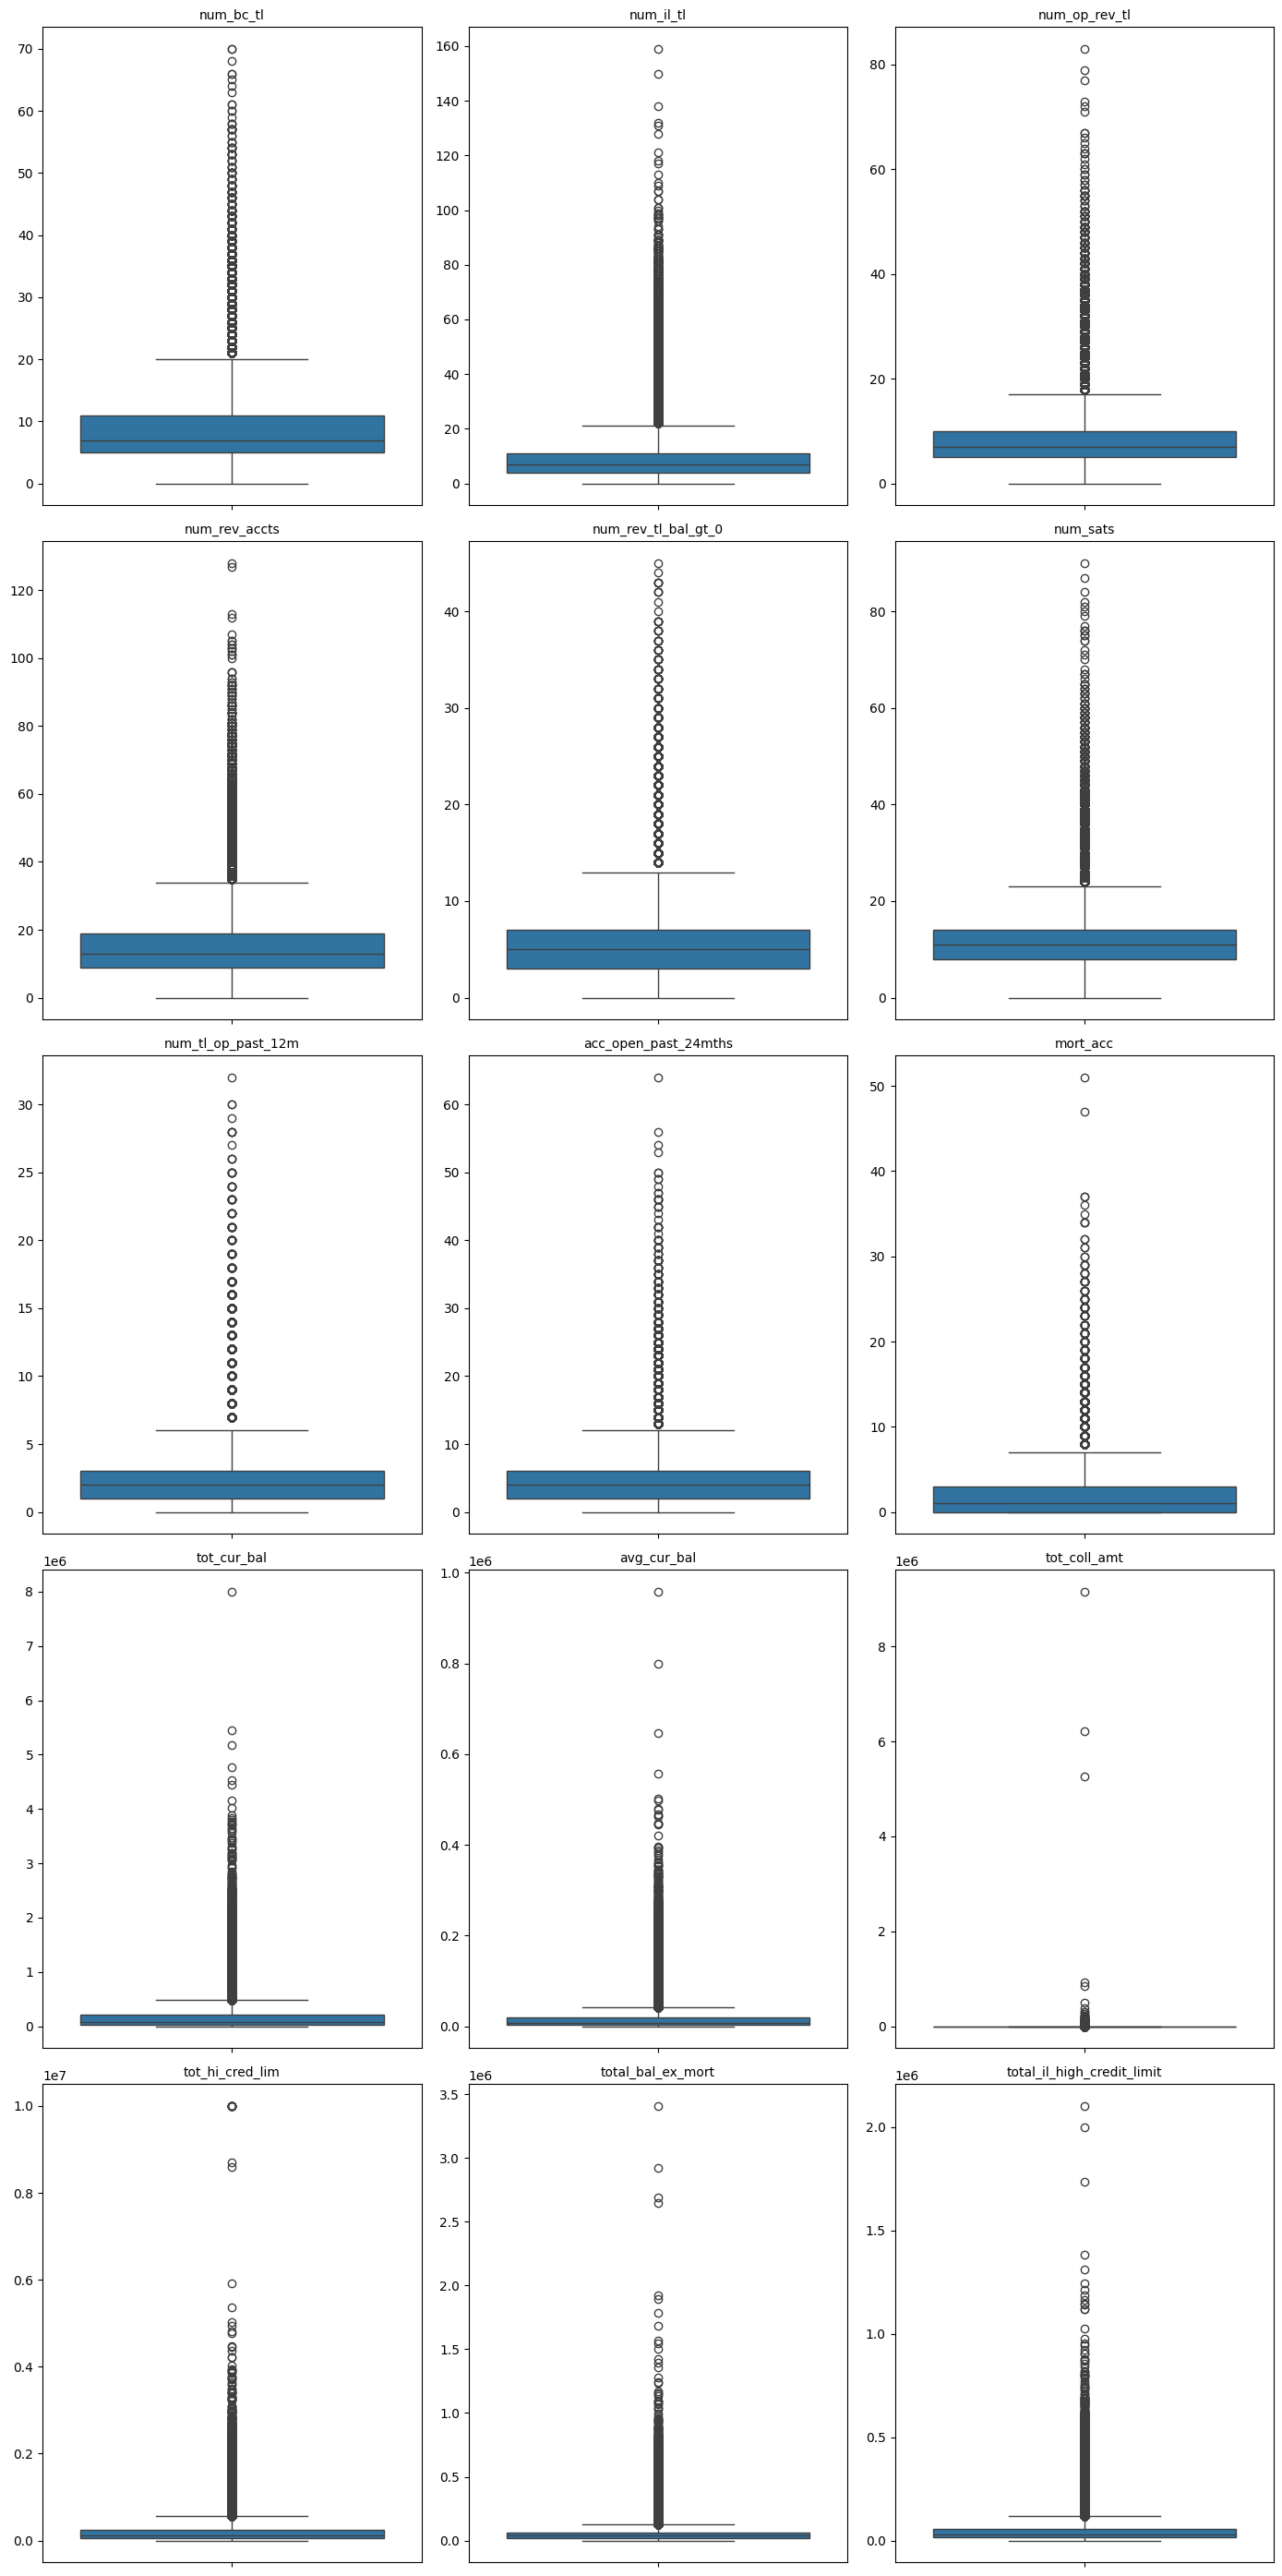

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(5, 3, figsize=(14, 28))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df_cleaned_v3[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()


# 이상치 해석
- 15개 컬럼에서 outlier는 모두 존재함
- 결측치의 유무가 근거가 되면 플래그 변수 생성
- 사용할 모델이 선형 모델이면 이상치의 영향을 많이 받고, 트리 기반 모델이면 이상치의 영향을 많이 받지 않아 이상치 처리가 크게 상관 없음
- 우린 여러 모델을 고려 중이라서 이상치 처리를 선호
- 카운트형 변수는 clip으로 99%를 기준점으로 설정 후 처리, 금액형은 log1p로 처리
    - clip : 설정한 기준점을 상한선으로 그 이상은 기준점에 해당하는 값으로 깎음
    - log : 작은 수는 조금 줄이고, 큰 수는 크게 줄임
    - 카운트형 :num_bc_tl, num_il_tl, num_op_rev_tl, num_rev_accts, num_rev_tl_bal_gt_0, num_sats,
    num_tl_op_past_12m, acc_open_past_24mths, mort_acc
    - 금액형 : tot_cur_bal, avg_cur_bal, tot_coll_amt, tot_hi_cred_lim, total_bal_ex_mort, total_il_high_credit_limit
-  tot_coll_amt컬럼은 데이터의 최소 75%가 0인 zero-inflated 변수임
    - 1. zero 플래그 생성 고려
    - 2. 0은 0으로 두고, 0이 아닌 값은 log를 적용해 큰 값의 꼬리를 완화하는 'log1p' 를 마찬가지로 적용

# 결측치 처리 방안 모색


In [56]:
tmp2= df_cleaned_v3.copy()

# 1) 결측 요약
na_summary = pd.DataFrame({
    "na_count": tmp2[cols].isna().sum(),
    "na_ratio": tmp2[cols].isna().mean()
}).sort_values("na_ratio", ascending=False)
display(na_summary)



,na_count,na_ratio
avg_cur_bal,67549,0.050209
num_rev_accts,67528,0.050194
num_il_tl,67527,0.050193
num_op_rev_tl,67527,0.050193
num_rev_tl_bal_gt_0,67527,0.050193
num_tl_op_past_12m,67527,0.050193
num_bc_tl,67527,0.050193
total_il_high_credit_limit,67527,0.050193
tot_cur_bal,67527,0.050193
tot_hi_cred_lim,67527,0.050193


In [104]:
# 1) 행별 결측치 개수 계산하여 새로운 컬럼으로 추가
tmp2['total_missing_in_row'] = tmp2.isnull().sum(axis=1)

# 2) issue_d를 datetime으로만 파싱(원본 issue_d는 유지)
tmp2['issue_d_dt'] = pd.to_datetime(tmp2['issue_d'], format='%b-%Y', errors='coerce')

# 3) 월별 평균 결측치 개수
yearmonth_missing_avg = (
    tmp2.groupby('issue_d_dt')['total_missing_in_row']
       .mean()
       .sort_index()
)
yearmonth_missing_avg.index = yearmonth_missing_avg.index.strftime('%b-%Y')

print(" [전체 컬럼 기준: issue_d(월)별 행당 평균 결측치 개수]")
print(yearmonth_missing_avg.round(2))
print("-" * 50)

# 4) 월별 불량 행 분포
threshold = 15
tmp2['is_high_missing'] = tmp2['total_missing_in_row'] >= threshold

yearmonth_missing_dist = (
    tmp2.groupby('issue_d_dt')['is_high_missing']
       .agg(['count', 'sum'])
       .sort_index()
)
yearmonth_missing_dist.columns = ['전체 대출 건수', f'결측치 {threshold}개 이상 (불량 행)']
yearmonth_missing_dist['불량 행 비율(%)'] = (
    yearmonth_missing_dist[f'결측치 {threshold}개 이상 (불량 행)'] /
    yearmonth_missing_dist['전체 대출 건수'] * 100
).round(2)

yearmonth_missing_dist.index = yearmonth_missing_dist.index.strftime('%b-%Y')

print(f"\n [전체 컬럼 기준: issue_d(월)별 불량 행(결측 {threshold}개 이상) 분포]")
print(yearmonth_missing_dist)


 [전체 컬럼 기준: issue_d(월)별 행당 평균 결측치 개수]
issue_d_dt
Jun-2007    42.00
Jul-2007    42.13
Aug-2007    40.88
Sep-2007    39.67
Oct-2007    39.11
Nov-2007    39.05
Dec-2007    39.04
Jan-2008    39.01
Feb-2008    38.99
Mar-2008    39.28
Apr-2008    39.52
May-2008    39.63
Jun-2008    39.50
Jul-2008    39.59
Aug-2008    39.42
Sep-2008    39.69
Oct-2008    39.56
Nov-2008    39.59
Dec-2008    39.60
Jan-2009    39.66
Feb-2009    39.62
Mar-2009    39.58
Apr-2009    39.70
May-2009    39.68
Jun-2009    39.67
Jul-2009    39.64
Aug-2009    39.70
Sep-2009    39.67
Oct-2009    39.73
Nov-2009    39.73
Dec-2009    39.75
Jan-2010    39.75
Feb-2010    39.74
Mar-2010    39.72
Apr-2010    39.64
May-2010    39.69
Jun-2010    39.67
Jul-2010    39.65
Aug-2010    39.64
Sep-2010    39.66
Oct-2010    39.68
Nov-2010    39.71
Dec-2010    39.71
Jan-2011    39.69
Feb-2011    39.74
Mar-2011    39.71
Apr-2011    39.68
May-2011    39.68
Jun-2011    39.66
Jul-2011    39.69
Aug-2011    39.68
Sep-2011    39.71
Oct-2011    39.

In [109]:
# 행별 결측치 개수 (전체 컬럼 기준)
missing_per_row = tmp2.isna().sum(axis=1)

# 결측치 15개 이상인 행을 불량 행으로 간주하는 기준 설정
tmp2['is_high_missing'] = missing_per_row >= threshold # is_high_missing 컬럼은 각 행이 결측치 15개 이상인지 여부를 True/False로 나타냄

# issue_d(월)별 불량행 비율
monthly_bad = (
    tmp2.groupby('issue_d_dt')['is_high_missing']
       .mean()
       .sort_index()
       .rename('bad_ratio')
       .to_frame()
)
monthly_bad['bad_count'] = tmp2.groupby('issue_d_dt')['is_high_missing'].sum().sort_index() # 월별 불량 행 개수
monthly_bad['total_count'] = tmp2.groupby('issue_d_dt')['is_high_missing'].size().sort_index() # 월별 전체 행 개수

display(monthly_bad)


,bad_ratio,bad_count,total_count
issue_d_dt,,,
2007-06-01,1.000000,1,1
2007-07-01,1.000000,30,30
2007-08-01,1.000000,33,33
2007-09-01,1.000000,18,18
2007-10-01,1.000000,47,47
2007-11-01,1.000000,37,37
2007-12-01,1.000000,85,85
2008-01-01,1.000000,171,171
2008-02-01,1.000000,174,174


In [ ]:
# 불량 행 비율이 1% 미만인 월을 True로 표시하는 조건
cond = monthly_bad['bad_ratio'] < 0.01 

# 6개월 연속으로 불량 행 비율이 1% 미만인 구간을 찾는 조건
run6 = cond.rolling(6, min_periods=6).sum() == 6 

if run6.any():
    end_idx = run6[run6].index[0]               # 첫 6개월 연속 구간의 마지막 월
    start_idx = monthly_bad.index[monthly_bad.index.get_loc(end_idx) - 5]  # 시작 월
    cutoff = start_idx
else:
    cutoff = None 
# if문은 6개월 연속으로 불량 행 비율이 1% 미만인 구간이 있는지 확인하고, 있다면 그 구간의 시작 월을 cutoff로 설정하는 로직입니다. 
# 만약 그런 구간이 없다면 cutoff는 None으로 설정됩니다.

print(cutoff)


2012-10-01 00:00:00


In [ ]:
if cutoff is not None:
    df_modern_era = tmp[tmp['issue_d_dt'] >= cutoff].copy() # cutoff 이후 데이터만 필터링하여 df_modern_era에 저장
    df_modern_era.drop(columns=['issue_d_dt', 'is_high_missing'], inplace=True, errors='ignore') # 분석 편의 위해 중간 계산 컬럼 제거
    print(f"cutoff 이후 데이터 형태(행, 열): {df_modern_era.shape}")

df_modern_era


cutoff 이후 데이터 형태(행, 열): (1270908, 75)


In [ ]:
# df_modern_era의 컬럼 이름 중 'issue_d_dt'와 'is_high_missing', 'total_missing_in_row' 제거하기

df_modern_era.drop(
    columns=['issue_d_dt', 'is_high_missing', 'total_missing_in_row'],
    inplace=True,
    errors='ignore'
)
print(df_modern_era.shape) # 최종적으로 df_modern_era에서 분석에 필요 없는 중간 계산 컬럼들을 제거하여 최종 데이터 형태를 출력하는 코드입니다.


(1270908, 74)


In [ ]:
# df_modern_era의 issue_d 컬럼을 확인하여 잘 필터링 되었는지 확인하기
print(df_modern_era['issue_d'].value_counts().sort_index()) 


issue_d
Apr-2013     9419
Apr-2014    18172
Apr-2015    31785
Apr-2016    24105
Apr-2017    13104
Apr-2018     6924
Aug-2013    12674
Aug-2014    17731
Aug-2015    31701
Aug-2016    22258
Aug-2017    15489
Aug-2018     3569
Dec-2012     6066
Dec-2013    15012
Dec-2014     9367
Dec-2015    39003
Dec-2016    19376
Dec-2017    10063
Dec-2018     1248
Feb-2013     7561
Feb-2014    15205
Feb-2015    21656
Feb-2016    34599
Feb-2017    13468
Feb-2018     6752
Jan-2013     6872
Jan-2014    15614
Jan-2015    32216
Jan-2016    28397
Jan-2017    16395
Jan-2018     8600
Jul-2013    11910
Jul-2014    27547
Jul-2015    41053
Jul-2016    21724
Jul-2017    14959
Jul-2018     4317
Jun-2013    10899
Jun-2014    16186
Jun-2015    25446
Jun-2016    20734
Jun-2017    15235
Jun-2018     4893
Mar-2013     8273
Mar-2014    16194
Mar-2015    22931
Mar-2016    48938
Mar-2017    17011
Mar-2018     7178
May-2013    10350
May-2014    18098
May-2015    28711
May-2016    18110
May-2017    16153
May-2018     6632
No

# 정리
- df_cleaned_v3에서 컬럼별 결측치 개수/비율 확인
- 결측률이 동일한 컬럼 묶음을 확인해 구조적 결측 가능성 점검
- issue_d 기준으로 결측 분포를 확인해 시간 편향 여부 분석
- 74개 기준 “행 결측치 15개 이상” 불량행을 집계했고, Sep-2012까지 비율이 높음을 확인
- 불량행 비율이 6개월 연속 1% 미만이 되는 첫 구간의 시작 월을 cutoff로 설정
- cutoff 이후 행만 남겨 df_modern_era 생성(이전 구간 drop)
- 계산용 파생 컬럼(issue_d_dt, is_high_missing, 기타 임시 컬럼) 제거
- 결측치 1차 정제 완료 (다음 단계: 컬럼별 대체/이상치 처리)

## PART 3 결측치가 있는 컬럼의 처리

In [118]:
# A 제거했을 경우
# 결측치가 하나라도 있는 컬럼 개수 확인

import pandas as pd

# 1. 잔여 결측치 확인 (빈칸이 1개라도 있는 컬럼만 추출)
missing_remaining = df_modern_era.isnull().sum() # mising_remaining은 각 컬럼별 결측치 개수를 담은 시리즈입니다.
missing_remaining = missing_remaining[missing_remaining > 0].sort_values(ascending=False) # 결측치가 1개라도 있는 컬럼들만 필터링하여 개수 기준으로 내림차순 정렬합니다.

# 2. 보기 쉽게 데이터프레임으로 변환하여 비율(%)과 함께 출력
missing_pct = (missing_remaining / len(df_modern_era)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_remaining, 
    'Missing Ratio (%)': missing_pct
}) # missing_info는 결측치 개수와 비율을 담은 데이터프레임입니다.

print(" [잔여 결측치 현황 ]")
print(missing_info)

print("잔여 결측치가 있는 컬럼 개수:",)
len(missing_info)

 [잔여 결측치 현황 ]
                                Missing Count  Missing Ratio (%)
mths_since_last_record                1046164          82.316265
mths_since_recent_bc_dlq               953225          75.003462
mths_since_last_major_derog            918190          72.246772
mths_since_recent_revol_delinq         827763          65.131622
mths_since_rcnt_il                     747489          58.815351
mths_since_last_delinq                 630300          49.594463
mths_since_recent_inq                  123249           9.697712
emp_title                               81266           6.394326
emp_length                              76255           6.000041
num_tl_120dpd_2m                        49877           3.924517
mo_sin_old_il_acct                      37664           2.963550
bc_util                                 14257           1.121796
percent_bc_gt_75                        13918           1.095123
bc_open_to_buy                          13506           1.062705
mths_since_

39

# 이후는 현수님 코드 참고